# Huấn luyện MAPPO trên MATE: Cấu hình Global Critic + Clip 0.10

Notebook này tách riêng khỏi `01_train_mappo_mate.ipynb` để phục vụ phần trình bày và phân tích.

Mục tiêu của vòng chạy này:
- dùng cấu hình đang đáng ưu tiên từ ablation ngắn: `critic_input_mode="global"`
- giữ `clip_range=0.10`
- train dài hơn để xem policy có cải thiện thật không
- giảm `entropy_coef` để kiểm tra xem entropy có bớt tăng và policy có ổn định hơn không
- log chi tiết để giải thích cho giảng viên bằng số liệu và biểu đồ

In [16]:
from pathlib import Path
import json
import time

import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mate
from mate.agents import GreedyTargetAgent
from gym_agent import MAPPO, MAPPOConfig

## Vì sao chọn cấu hình này

Từ kết quả `ablation` trước đó:
- `clip_range=0.10` cho `critic_loss` tốt hơn `0.05`
- `critic_input_mode="global"` đang cho `critic_loss` thấp hơn `agent_specific`
- entropy vẫn còn cao, nên vòng chạy này giảm `entropy_coef` để hạn chế policy quá phân tán

Ý tưởng chính của notebook này là kiểm tra xem khi train dài hơn, cấu hình trên có:
- giảm `critic_loss` ổn định hơn không
- làm entropy bớt cao không
- cải thiện `eval reward`, `coverage`, `transport`, `delivered cargoes` hay không

In [17]:
RUN_NAME = "mappo_global_clip010_entropy0005"
CONFIG_NAME = "MATE-8v8-9.yaml"

CHECKPOINT_DIR = Path("checkpoints")
RESULTS_DIR = Path("results")
CHECKPOINT_PATH = CHECKPOINT_DIR / f"{RUN_NAME}.pt"
BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / f"{RUN_NAME}_best_eval.pt"
TRAIN_HISTORY_CSV = RESULTS_DIR / f"{RUN_NAME}_train_history.csv"
TRAIN_HISTORY_JSON = RESULTS_DIR / f"{RUN_NAME}_train_history.json"
EVAL_HISTORY_CSV = RESULTS_DIR / f"{RUN_NAME}_eval_history.csv"
CONFIG_SNAPSHOT_JSON = RESULTS_DIR / f"{RUN_NAME}_config.json"

TOTAL_ENV_STEPS = 200_000
TRAIN_CHUNK_STEPS = 20_000
EVAL_EVERY_STEPS = 20_000
EVAL_EPISODES = 5
EVAL_MAX_STEPS = 500

NUM_ENVS = 8
ROLLOUT_LENGTH = 400
N_EPOCHS = 5
NUM_MINI_BATCHES = 1
RECURRENT_CHUNK_LENGTH = 20
CRITIC_INPUT_MODE = "global"
CLIP_RANGE = 0.10
ENTROPY_COEF = 0.005
SEED = 42

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

config = MAPPOConfig(
    env_config=CONFIG_NAME,
    num_envs=NUM_ENVS,
    rollout_length=ROLLOUT_LENGTH,
    n_epochs=N_EPOCHS,
    num_mini_batches=NUM_MINI_BATCHES,
    recurrent_chunk_length=RECURRENT_CHUNK_LENGTH,
    critic_input_mode=CRITIC_INPUT_MODE,
    clip_range=CLIP_RANGE,
    entropy_coef=ENTROPY_COEF,
    device="cpu",
    render_mode="rgb_array",
    seed=SEED,
)

config_snapshot = {
    "run_name": RUN_NAME,
    "total_env_steps": TOTAL_ENV_STEPS,
    "train_chunk_steps": TRAIN_CHUNK_STEPS,
    "eval_every_steps": EVAL_EVERY_STEPS,
    "eval_episodes": EVAL_EPISODES,
    "eval_max_steps": EVAL_MAX_STEPS,
    "critic_input_mode": CRITIC_INPUT_MODE,
    "clip_range": CLIP_RANGE,
    "entropy_coef": ENTROPY_COEF,
    "num_envs": NUM_ENVS,
    "rollout_length": ROLLOUT_LENGTH,
    "n_epochs": N_EPOCHS,
    "num_mini_batches": NUM_MINI_BATCHES,
    "recurrent_chunk_length": RECURRENT_CHUNK_LENGTH,
    "seed": SEED,
}

CONFIG_SNAPSHOT_JSON.write_text(json.dumps(config_snapshot, indent=2), encoding="utf-8")
pd.DataFrame([config_snapshot])

,run_name,total_env_steps,train_chunk_steps,eval_every_steps,eval_episodes,eval_max_steps,critic_input_mode,clip_range,entropy_coef,num_envs,rollout_length,n_epochs,num_mini_batches,recurrent_chunk_length,seed
0,mappo_global_clip010_entropy0005,200000,20000,20000,5,500,global,0.1,0.005,8,400,5,1,20,42


## Hàm hỗ trợ

Phần này tạo môi trường đánh giá và hàm đo các chỉ số định kỳ.

In [18]:
def make_camera_env(render_mode="rgb_array"):
    base_env = gym.make(
        "MultiAgentTracking-v0",
        config=CONFIG_NAME,
        render_mode=render_mode,
    )
    return mate.MultiCamera.make(
        base_env,
        target_agent=GreedyTargetAgent(),
    )


def evaluate_current_agent(agent, episodes=EVAL_EPISODES, max_steps=EVAL_MAX_STEPS):
    env = make_camera_env()
    rows = []
    try:
        for episode_idx in range(1, episodes + 1):
            observation, _ = env.reset(seed=episode_idx)
            actor_hidden_state = None
            episode_start = None
            episode_reward = 0.0
            coverage_rate = float(getattr(env.unwrapped, "coverage_rate", np.nan))
            transport_rate = float(getattr(env.unwrapped, "mean_transport_rate", np.nan))
            delivered_cargoes = float(getattr(env.unwrapped, "num_delivered_cargoes", 0.0))

            for _ in range(1, max_steps + 1):
                action, actor_hidden_state = agent.predict(
                    observation,
                    actor_hidden_state=actor_hidden_state,
                    episode_start=episode_start,
                    deterministic=True,
                )
                observation, reward, terminated, truncated, info = env.step(action)
                reward_value = float(np.mean(reward)) if not np.isscalar(reward) else float(reward)
                episode_reward += reward_value
                done = bool(terminated or truncated)
                episode_start = np.full(env.unwrapped.num_cameras, done, dtype=np.bool_)

                if isinstance(info, list) and len(info) > 0:
                    coverage_rate = float(info[0].get("coverage_rate", getattr(env.unwrapped, "coverage_rate", np.nan)))
                    transport_rate = float(info[0].get("mean_transport_rate", getattr(env.unwrapped, "mean_transport_rate", np.nan)))
                    delivered_cargoes = float(info[0].get("num_delivered_cargoes", getattr(env.unwrapped, "num_delivered_cargoes", 0.0)))
                else:
                    coverage_rate = float(getattr(env.unwrapped, "coverage_rate", np.nan))
                    transport_rate = float(getattr(env.unwrapped, "mean_transport_rate", np.nan))
                    delivered_cargoes = float(getattr(env.unwrapped, "num_delivered_cargoes", 0.0))

                if done:
                    break

            rows.append(
                {
                    "episode_reward": episode_reward,
                    "coverage_rate": coverage_rate,
                    "transport_rate": transport_rate,
                    "delivered_cargoes": delivered_cargoes,
                }
            )
    finally:
        env.close()

    eval_df = pd.DataFrame(rows)
    return {
        "eval_episode_reward": float(eval_df["episode_reward"].mean()),
        "eval_episode_reward_std": float(eval_df["episode_reward"].std(ddof=0)),
        "eval_coverage_rate": float(eval_df["coverage_rate"].mean()),
        "eval_transport_rate": float(eval_df["transport_rate"].mean()),
        "eval_delivered_cargoes": float(eval_df["delivered_cargoes"].mean()),
    }

## Huấn luyện chi tiết

Cell này train theo từng `chunk`, lưu đầy đủ log train và log đánh giá. Ngoài checkpoint cuối, notebook còn lưu checkpoint tốt nhất theo `eval_episode_reward`.

In [19]:
agent = MAPPO(config=config)
history = []
last_eval_step = 0
best_eval_reward = None
num_chunks = (TOTAL_ENV_STEPS + TRAIN_CHUNK_STEPS - 1) // TRAIN_CHUNK_STEPS

try:
    for chunk_idx in range(1, num_chunks + 1):
        start_time = time.time()
        target_steps = min(agent.total_env_steps + TRAIN_CHUNK_STEPS, TOTAL_ENV_STEPS)
        stats = agent.learn(total_env_steps=target_steps)
        elapsed = time.time() - start_time
        current_env_steps = int(stats["total_env_steps"])
        progress = 100.0 * current_env_steps / TOTAL_ENV_STEPS

        record = {
            "chunk": chunk_idx,
            "env_steps": current_env_steps,
            "agent_steps": int(stats["total_agent_steps"]),
            "actor_loss": float(stats["actor_loss"]),
            "critic_loss": float(stats["critic_loss"]),
            "entropy": float(stats["entropy"]),
            "completed_episodes": int(stats["completed_episodes"]),
            "chunk_time_sec": float(elapsed),
            "progress_percent": float(progress),
            "critic_input_mode": config.critic_input_mode,
            "clip_range": config.clip_range,
            "entropy_coef": config.entropy_coef,
            "did_evaluate": False,
            "is_best_eval": False,
        }

        checkpoint_step_path = CHECKPOINT_DIR / f"{RUN_NAME}_step_{current_env_steps}.pt"
        agent.save(checkpoint_step_path)
        agent.save(CHECKPOINT_PATH)

        should_eval = (current_env_steps - last_eval_step >= EVAL_EVERY_STEPS) or (current_env_steps >= TOTAL_ENV_STEPS)
        if should_eval:
            eval_stats = evaluate_current_agent(agent)
            record.update(eval_stats)
            record["did_evaluate"] = True
            last_eval_step = current_env_steps

            current_eval_reward = record["eval_episode_reward"]
            if best_eval_reward is None or current_eval_reward > best_eval_reward:
                best_eval_reward = current_eval_reward
                record["is_best_eval"] = True
                agent.save(BEST_CHECKPOINT_PATH)

        history.append(record)
        history_df = pd.DataFrame(history)
        history_df.to_csv(TRAIN_HISTORY_CSV, index=False)
        history_df[history_df["did_evaluate"]].to_csv(EVAL_HISTORY_CSV, index=False)
        TRAIN_HISTORY_JSON.write_text(json.dumps(history, indent=2), encoding="utf-8")

        print(
            f"Chunk {chunk_idx}/{num_chunks} | "
            f"env_steps={current_env_steps} | "
            f"tiến độ={progress:.2f}% | "
            f"actor_loss={record['actor_loss']:.4f} | "
            f"critic_loss={record['critic_loss']:.4f} | "
            f"entropy={record['entropy']:.4f} | "
            f"completed_episodes={record['completed_episodes']} | "
            f"thời gian={elapsed:.2f}s"
        )

        if record["did_evaluate"]:
            print(
                f"  Eval | reward={record['eval_episode_reward']:.3f} ± {record['eval_episode_reward_std']:.3f} | "
                f"coverage={record['eval_coverage_rate']:.3f} | "
                f"transport={record['eval_transport_rate']:.3f} | "
                f"cargo={record['eval_delivered_cargoes']:.2f} | "
                f"best={record['is_best_eval']}"
            )
        print()

    history_df = pd.DataFrame(history)
    display(history_df.tail(10))

    print(f"Đã lưu checkpoint cuối cùng tại: {CHECKPOINT_PATH}")
    print(f"Đã lưu checkpoint tốt nhất theo eval tại: {BEST_CHECKPOINT_PATH}")
    print(f"Đã lưu lịch sử huấn luyện tại: {TRAIN_HISTORY_CSV}")
    print(f"Đã lưu lịch sử đánh giá tại: {EVAL_HISTORY_CSV}")
finally:
    agent.close()

KeyboardInterrupt: 

In [ ]:
history_df = pd.read_csv(TRAIN_HISTORY_CSV)
history_df.tail()

,chunk,env_steps,agent_steps,actor_loss,critic_loss,entropy,completed_episodes,chunk_time_sec,progress_percent,critic_input_mode,clip_range,entropy_coef,did_evaluate,is_best_eval,eval_episode_reward,eval_episode_reward_std,eval_coverage_rate,eval_transport_rate,eval_delivered_cargoes
5,6,134400,1075200,-0.016377,0.342725,3.272551,107,49.676102,67.2,global,0.1,0.005,True,True,-3726.6,359.324143,0.150,0.623258,31.6
6,7,156800,1254400,-0.016454,0.367142,3.248581,125,49.260866,78.4,global,0.1,0.005,True,False,-4055.6,267.349659,0.400,0.668942,31.8
7,8,179200,1433600,-0.016593,0.369441,3.272329,142,48.768477,89.6,global,0.1,0.005,True,False,-3748.6,271.065748,0.375,0.646503,31.0
8,9,201600,1612800,-0.016665,0.343215,3.302961,159,49.306608,100.8,global,0.1,0.005,True,False,-3935.0,302.115210,0.300,0.674961,30.8
9,10,201600,1612800,-0.016665,0.343215,3.302961,159,0.000002,100.8,global,0.1,0.005,True,False,-4084.4,215.771731,0.275,0.685871,31.2


## Biểu đồ phân tích

Các biểu đồ dưới đây dùng để giải thích quá trình học của MAPPO theo thời gian.

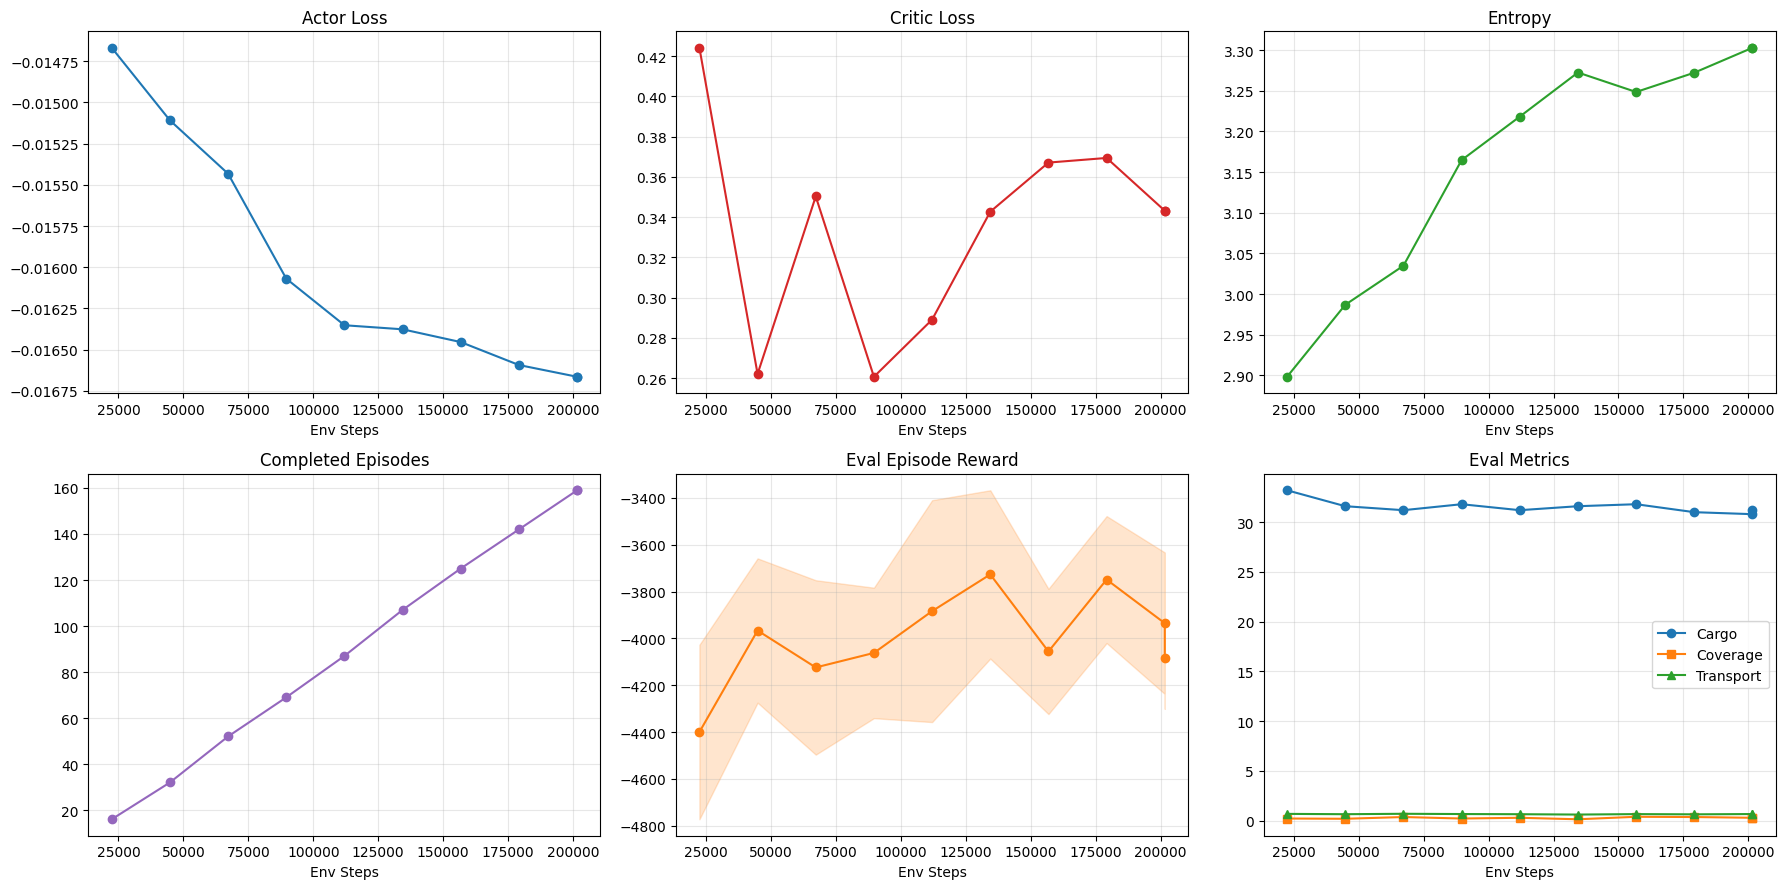

In [ ]:
history_df = pd.read_csv(TRAIN_HISTORY_CSV)
eval_df = pd.read_csv(EVAL_HISTORY_CSV) if EVAL_HISTORY_CSV.exists() else pd.DataFrame()

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

axes[0].plot(history_df["env_steps"], history_df["actor_loss"], marker="o")
axes[0].set_title("Actor Loss")
axes[0].set_xlabel("Env Steps")

axes[1].plot(history_df["env_steps"], history_df["critic_loss"], marker="o", color="tab:red")
axes[1].set_title("Critic Loss")
axes[1].set_xlabel("Env Steps")

axes[2].plot(history_df["env_steps"], history_df["entropy"], marker="o", color="tab:green")
axes[2].set_title("Entropy")
axes[2].set_xlabel("Env Steps")

axes[3].plot(history_df["env_steps"], history_df["completed_episodes"], marker="o", color="tab:purple")
axes[3].set_title("Completed Episodes")
axes[3].set_xlabel("Env Steps")

if not eval_df.empty:
    axes[4].plot(eval_df["env_steps"], eval_df["eval_episode_reward"], marker="o", color="tab:orange")
    axes[4].fill_between(
        eval_df["env_steps"],
        eval_df["eval_episode_reward"] - eval_df["eval_episode_reward_std"],
        eval_df["eval_episode_reward"] + eval_df["eval_episode_reward_std"],
        alpha=0.2,
        color="tab:orange",
    )
    axes[4].set_title("Eval Episode Reward")
    axes[4].set_xlabel("Env Steps")

    axes[5].plot(eval_df["env_steps"], eval_df["eval_delivered_cargoes"], marker="o", label="Cargo")
    if "eval_coverage_rate" in eval_df.columns:
        axes[5].plot(eval_df["env_steps"], eval_df["eval_coverage_rate"], marker="s", label="Coverage")
    if "eval_transport_rate" in eval_df.columns:
        axes[5].plot(eval_df["env_steps"], eval_df["eval_transport_rate"], marker="^", label="Transport")
    axes[5].set_title("Eval Metrics")
    axes[5].set_xlabel("Env Steps")
    axes[5].legend()
else:
    axes[4].set_visible(False)
    axes[5].set_visible(False)

for ax in axes:
    if ax.get_visible():
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Tóm tắt kết quả sau khi chạy

Cell này giúp đọc nhanh xu hướng để trình bày: entropy tăng hay giảm, critic loss ổn định hay không, reward và các metric môi trường có cải thiện hay chưa.

In [ ]:
history_df = pd.read_csv(TRAIN_HISTORY_CSV)
eval_df = pd.read_csv(EVAL_HISTORY_CSV) if EVAL_HISTORY_CSV.exists() else pd.DataFrame()

first_train = history_df.iloc[0]
last_train = history_df.iloc[-1]

print("Tóm tắt train:")
print(f"- Actor loss: {first_train['actor_loss']:.4f} -> {last_train['actor_loss']:.4f}")
print(f"- Critic loss: {first_train['critic_loss']:.4f} -> {last_train['critic_loss']:.4f}")
print(f"- Entropy: {first_train['entropy']:.4f} -> {last_train['entropy']:.4f}")
print(f"- Completed episodes: {int(first_train['completed_episodes'])} -> {int(last_train['completed_episodes'])}")

if not eval_df.empty:
    first_eval = eval_df.iloc[0]
    best_eval = eval_df.sort_values('eval_episode_reward', ascending=False).iloc[0]
    last_eval = eval_df.iloc[-1]
    print()
    print("Tóm tắt eval:")
    print(f"- Eval reward đầu tiên: {first_eval['eval_episode_reward']:.3f}")
    print(f"- Eval reward tốt nhất: {best_eval['eval_episode_reward']:.3f} tại {int(best_eval['env_steps'])} env steps")
    print(f"- Eval reward cuối cùng: {last_eval['eval_episode_reward']:.3f}")
    print(f"- Coverage cuối cùng: {last_eval['eval_coverage_rate']:.3f}")
    print(f"- Transport cuối cùng: {last_eval['eval_transport_rate']:.3f}")
    print(f"- Delivered cargoes cuối cùng: {last_eval['eval_delivered_cargoes']:.2f}")

print()
print("Gợi ý diễn giải:")
if last_train['entropy'] > first_train['entropy']:
    print("- Entropy tăng: policy còn phân tán, mức khám phá vẫn cao, mô hình có thể chưa hội tụ.")
else:
    print("- Entropy giảm hoặc ổn định: policy đang bớt ngẫu nhiên hơn.")

if last_train['critic_loss'] < first_train['critic_loss']:
    print("- Critic loss giảm: critic đang học giá trị ổn định hơn so với đầu quá trình.")
else:
    print("- Critic loss chưa giảm rõ: cần xem lại critic input hoặc thời lượng train.")

if not eval_df.empty and eval_df['eval_episode_reward'].iloc[-1] > eval_df['eval_episode_reward'].iloc[0]:
    print("- Eval reward có cải thiện so với mốc đầu tiên.")
elif not eval_df.empty:
    print("- Eval reward chưa cải thiện rõ; cần xem thêm coverage, transport và cargo để tránh đánh giá chỉ theo reward tổng.")

Tóm tắt train:
- Actor loss: -0.0147 -> -0.0167
- Critic loss: 0.4242 -> 0.3432
- Entropy: 2.8983 -> 3.3030
- Completed episodes: 16 -> 159

Tóm tắt eval:
- Eval reward đầu tiên: -4399.600
- Eval reward tốt nhất: -3726.600 tại 134400 env steps
- Eval reward cuối cùng: -4084.400
- Coverage cuối cùng: 0.275
- Transport cuối cùng: 0.686
- Delivered cargoes cuối cùng: 31.20

Gợi ý diễn giải:
- Entropy tăng: policy còn phân tán, mức khám phá vẫn cao, mô hình có thể chưa hội tụ.
- Critic loss giảm: critic đang học giá trị ổn định hơn so với đầu quá trình.
- Eval reward có cải thiện so với mốc đầu tiên.


## Đánh Giá Lại Với Metric Đúng

Cell này dùng lại checkpoint đã train xong và chạy đánh giá lại để lấy `coverage_rate`, `mean_transport_rate` và `num_delivered_cargoes` từ `info`/`env.unwrapped` thay vì đọc nhầm từ wrapper ngoài.

Lưu ý: cell này **không train lại model**. Nó chỉ đánh giá lại checkpoint tốt nhất hoặc checkpoint cuối.

In [ ]:
REEVAL_CHECKPOINT_PATH = BEST_CHECKPOINT_PATH if BEST_CHECKPOINT_PATH.exists() else CHECKPOINT_PATH
REEVAL_EPISODES = 10
REEVAL_CSV = RESULTS_DIR / f"{RUN_NAME}_reeval_fixed_metrics.csv"

def evaluate_checkpoint_with_fixed_metrics(checkpoint_path, episodes=REEVAL_EPISODES, max_steps=EVAL_MAX_STEPS):
    agent = MAPPO.load(checkpoint_path)
    env = make_camera_env()
    rows = []
    try:
        for episode_idx in range(1, episodes + 1):
            observation, _ = env.reset(seed=episode_idx)
            actor_hidden_state = None
            episode_start = None
            episode_reward = 0.0
            coverage_rate = float(getattr(env.unwrapped, "coverage_rate", np.nan))
            transport_rate = float(getattr(env.unwrapped, "mean_transport_rate", np.nan))
            delivered_cargoes = float(getattr(env.unwrapped, "num_delivered_cargoes", 0.0))

            for _ in range(1, max_steps + 1):
                action, actor_hidden_state = agent.predict(
                    observation,
                    actor_hidden_state=actor_hidden_state,
                    episode_start=episode_start,
                    deterministic=True,
                )
                observation, reward, terminated, truncated, info = env.step(action)
                reward_value = float(np.mean(reward)) if not np.isscalar(reward) else float(reward)
                episode_reward += reward_value
                done = bool(terminated or truncated)
                episode_start = np.full(env.unwrapped.num_cameras, done, dtype=np.bool_)

                if isinstance(info, list) and len(info) > 0:
                    coverage_rate = float(info[0].get("coverage_rate", getattr(env.unwrapped, "coverage_rate", np.nan)))
                    transport_rate = float(info[0].get("mean_transport_rate", getattr(env.unwrapped, "mean_transport_rate", np.nan)))
                    delivered_cargoes = float(info[0].get("num_delivered_cargoes", getattr(env.unwrapped, "num_delivered_cargoes", 0.0)))
                else:
                    coverage_rate = float(getattr(env.unwrapped, "coverage_rate", np.nan))
                    transport_rate = float(getattr(env.unwrapped, "mean_transport_rate", np.nan))
                    delivered_cargoes = float(getattr(env.unwrapped, "num_delivered_cargoes", 0.0))

                if done:
                    break

            rows.append({
                "episode": episode_idx,
                "checkpoint": str(checkpoint_path),
                "episode_reward": episode_reward,
                "coverage_rate": coverage_rate,
                "transport_rate": transport_rate,
                "delivered_cargoes": delivered_cargoes,
            })
    finally:
        env.close()
        agent.close()

    return pd.DataFrame(rows)

reeval_df = evaluate_checkpoint_with_fixed_metrics(REEVAL_CHECKPOINT_PATH)
reeval_df.to_csv(REEVAL_CSV, index=False)
display(reeval_df)
print(f"Đã lưu kết quả đánh giá lại tại: {REEVAL_CSV}")
print()
print("Trung bình sau khi sửa cách đọc metric:")
print(f"- Reward: {reeval_df['episode_reward'].mean():.3f}")
print(f"- Coverage rate: {reeval_df['coverage_rate'].mean():.3f}")
print(f"- Transport rate: {reeval_df['transport_rate'].mean():.3f}")
print(f"- Delivered cargoes: {reeval_df['delivered_cargoes'].mean():.3f}")


,episode,checkpoint,episode_reward,coverage_rate,transport_rate,delivered_cargoes
0,1,checkpoints/mappo_global_clip010_entropy0005_b...,-3295.0,0.500,0.583871,31.0
1,2,checkpoints/mappo_global_clip010_entropy0005_b...,-3341.0,0.375,0.597419,31.0
2,3,checkpoints/mappo_global_clip010_entropy0005_b...,-3669.0,0.125,0.675517,29.0
3,4,checkpoints/mappo_global_clip010_entropy0005_b...,-3466.0,0.500,0.625667,30.0
4,5,checkpoints/mappo_global_clip010_entropy0005_b...,-3542.0,0.000,0.608065,31.0
5,6,checkpoints/mappo_global_clip010_entropy0005_b...,-3152.0,0.500,0.541935,31.0
6,7,checkpoints/mappo_global_clip010_entropy0005_b...,-3703.0,0.500,0.619375,32.0
7,8,checkpoints/mappo_global_clip010_entropy0005_b...,-4675.0,0.250,0.726061,33.0
8,9,checkpoints/mappo_global_clip010_entropy0005_b...,-3992.0,0.000,0.614706,34.0
9,10,checkpoints/mappo_global_clip010_entropy0005_b...,-4255.0,0.250,0.687187,32.0


Đã lưu kết quả đánh giá lại tại: results/mappo_global_clip010_entropy0005_reeval_fixed_metrics.csv

Trung bình sau khi sửa cách đọc metric:
- Reward: -3709.000
- Coverage rate: 0.300
- Transport rate: 0.628
- Delivered cargoes: 31.400
